# Who Moves Markets? Wealth Concentration and Capital Market Influence in the U.S.

Laura Huepenbecker


---

## Research Question

To what extent does wealth concentration among the top 1% of U.S. households determine the structure of U.S. capital markets — and how does this concentration respond to economic shocks?

## Background

Standard economic theory treats capital markets as driven by the aggregate behavior of a broad investor base. But if ownership of financial assets is heavily concentrated in a small number of households, market dynamics may be disproportionately shaped by the preferences, risk tolerance, and portfolio decisions of a very small fraction of the population.

The Federal Reserve's **Distributional Financial Accounts (DFA)** provide a rare empirical window into this question. Since 1989, the Fed has published quarterly estimates of the level and share of each household balance sheet item — net worth, corporate equities, real estate, financial assets — allocated across four wealth percentile groups:
- **Top 1%** (99th–100th percentile)
- **Next 9%** (90th–99th percentile)
- **Middle 40%** (50th–90th percentile)
- **Bottom 50%** (1st–50th percentile)

This notebook uses that data to investigate four complementary questions:
1. How has the net worth share of the top 1% vs. the bottom 50% evolved since 1989?
2. Who owns U.S. corporate equities — and by how much?
3. How does asset composition differ across wealth tiers, and what does that imply for market influence?
4. Do economic crises concentrate or temporarily redistribute wealth?

**Hypothesis:** If the top 1% holds a disproportionate and growing share of corporate equities, and if their portfolios are dominated by financial instruments rather than real estate, then wealth concentration is not merely a distributional outcome — it is a structural driver of capital market behavior.

---
## Setup

We use standard scientific Python libraries available on the LEAP Hub. No additional installation is needed.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

---
## Loading the Data

All data comes from the Federal Reserve's Distributional Financial Accounts (DFA), accessed directly via FRED's public CSV download API — no manual download steps required. Each URL follows the pattern `https://fred.stlouisfed.org/graph/fredgraph.csv?id=SERIES_ID`.

We load two types of series:
- **Share series** (`WFRBS...`): each group's percentage of the U.S. total — used in Figures 1, 2, and 4
- **Level series** (`WFRBLT...`, `WFRBLB...`): dollar amounts in billions — used in Figure 3

All series run quarterly from Q3 1989 to Q1 2026.

In [6]:
# Base URL for FRED CSV downloads — no API key required
FRED = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id='

In [7]:
# --- Net worth SHARE by wealth group ---
nw_top1  = pd.read_csv(FRED + 'WFRBST01134', index_col=0, parse_dates=True).squeeze()
nw_next9 = pd.read_csv(FRED + 'WFRBSN09161', index_col=0, parse_dates=True).squeeze()
nw_mid40 = pd.read_csv(FRED + 'WFRBSN40188', index_col=0, parse_dates=True).squeeze()
nw_bot50 = pd.read_csv(FRED + 'WFRBSB50215', index_col=0, parse_dates=True).squeeze()

In [9]:
eq_mid40 = pd.read_csv(FRED + 'WFRBSN40176', index_col=0, parse_dates=True).squeeze()
eq_bot50 = pd.read_csv(FRED + 'WFRBSB50203', index_col=0, parse_dates=True).squeeze()

In [11]:
# --- Equity (corporate equities + mutual funds) SHARE by wealth group ---
eq_top1  = pd.read_csv(FRED + 'WFRBST01122', index_col=0, parse_dates=True).squeeze()
eq_next9 = pd.read_csv(FRED + 'WFRBSN09136', index_col=0, parse_dates=True).squeeze()
eq_mid40 = pd.read_csv(FRED + 'WFRBSN40176', index_col=0, parse_dates=True).squeeze()
eq_bot50 = pd.read_csv(FRED + 'WFRBSB50203', index_col=0, parse_dates=True).squeeze()

In [12]:
# --- Asset LEVELS by group (billions of dollars) --- for Figure 3
eq_lev_top1  = pd.read_csv(FRED + 'WFRBLT01014', index_col=0, parse_dates=True).squeeze()
re_lev_top1  = pd.read_csv(FRED + 'WFRBLT01018', index_col=0, parse_dates=True).squeeze()
fa_lev_top1  = pd.read_csv(FRED + 'WFRBLT01006', index_col=0, parse_dates=True).squeeze()

In [13]:
# --- Asset LEVELS by group (billions of dollars) --- for Figure 3
eq_lev_top1  = pd.read_csv(FRED + 'WFRBLT01014', index_col=0, parse_dates=True).squeeze()
re_lev_top1  = pd.read_csv(FRED + 'WFRBLT01018', index_col=0, parse_dates=True).squeeze()
fa_lev_top1  = pd.read_csv(FRED + 'WFRBLT01006', index_col=0, parse_dates=True).squeeze()

eq_lev_bot50 = pd.read_csv(FRED + 'WFRBLB50095', index_col=0, parse_dates=True).squeeze()
re_lev_bot50 = pd.read_csv(FRED + 'WFRBLB50099', index_col=0, parse_dates=True).squeeze()
fa_lev_bot50 = pd.read_csv(FRED + 'WFRBLB50085', index_col=0, parse_dates=True).squeeze()

In [14]:
print('Data loaded successfully.')
print('Date range:', nw_top1.index[0].date(), 'to', nw_top1.index[-1].date())
print('Observations per series:', len(nw_top1))

Data loaded successfully.
Date range: 1989-07-01 to 2026-01-01
Observations per series: 147


### Assemble and inspect the net worth share DataFrame

We combine the four net worth share series into a single DataFrame and verify that shares sum to approximately 100% — a basic sanity check on the data.

In [5]:
nw = pd.DataFrame({
    'Top 1%':     nw_top1,
    'Next 9%':    nw_next9,
    'Middle 40%': nw_mid40,
    'Bottom 50%': nw_bot50,
}).dropna()

row_sums = nw.sum(axis=1)
print('Row sum — min: {:.1f}%  max: {:.1f}%  (should be ~100%)'.format(
    row_sums.min(), row_sums.max()))

nw.tail()

Row sum — min: 99.8%  max: 100.1%  (should be ~100%)


,Top 1%,Next 9%,Middle 40%,Bottom 50%
observation_date,,,,
2025-01-01,30.9,36.4,30.2,2.5
2025-04-01,31.2,36.4,30.0,2.5
2025-07-01,31.6,36.4,29.5,2.5
2025-10-01,31.8,36.4,29.3,2.5
2026-01-01,31.6,36.3,29.6,2.5


---
## Figure 1: Net Worth Share Over Time (1989–2025)

How has the distribution of total U.S. household net worth shifted across wealth groups over the past 35 years? We annotate major economic events to show how recessions and recoveries affect the trajectory of wealth concentration.

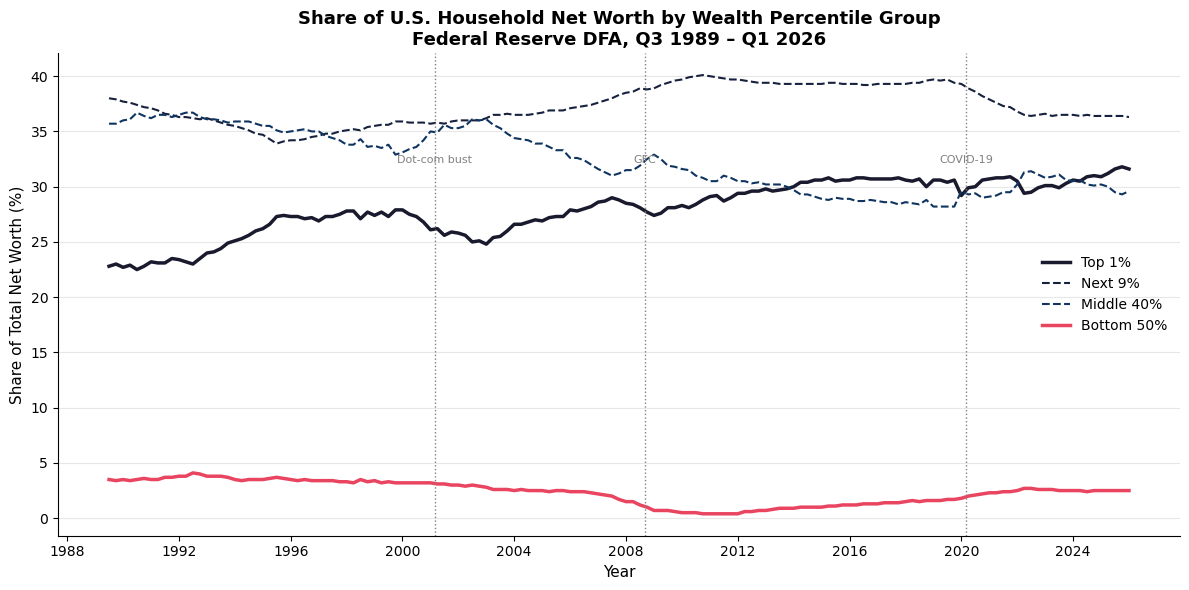

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(nw.index, nw['Top 1%'],     label='Top 1%',     color='#1a1a2e', linewidth=2.5)
ax.plot(nw.index, nw['Next 9%'],    label='Next 9%',    color='#16213e', linewidth=1.5, linestyle='--')
ax.plot(nw.index, nw['Middle 40%'], label='Middle 40%', color='#0f3460', linewidth=1.5, linestyle='--')
ax.plot(nw.index, nw['Bottom 50%'], label='Bottom 50%', color='#e94560', linewidth=2.5)

for date, label in [('2001-03-01', 'Dot-com bust'),
                    ('2008-09-01', 'GFC'),
                    ('2020-03-01', 'COVID-19')]:
    ax.axvline(pd.Timestamp(date), color='gray', linewidth=1, linestyle=':')
    ax.text(pd.Timestamp(date), nw['Top 1%'].max() * 1.01, label,
            ha='center', fontsize=8, color='gray')

ax.set_title('Share of U.S. Household Net Worth by Wealth Percentile Group\n'
             'Federal Reserve DFA, Q3 1989 – Q1 2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Share of Total Net Worth (%)', fontsize=11)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_net_worth_share.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The top 1%'s share of net worth has grown from roughly 23–24% in the early 1990s to over 30% by the mid-2020s. The bottom 50%'s share has remained near zero — or briefly turned negative during the 2008–09 mortgage crisis, when liabilities exceeded assets for many households. This sets up the central question: *what type of wealth* is driving this divergence, and does the composition of that wealth give the top 1% outsized market influence?

---
## Figure 2: Equity Ownership Concentration — Who Owns the Stock Market?

Net worth includes real estate, business equity, and financial assets. To understand capital market influence specifically, we zoom into **corporate equities and mutual fund shares** — the asset class most directly tied to market prices, corporate governance, and capital allocation. We show the full stacked picture alongside a direct comparison of the top 1%'s equity share vs. their net worth share.

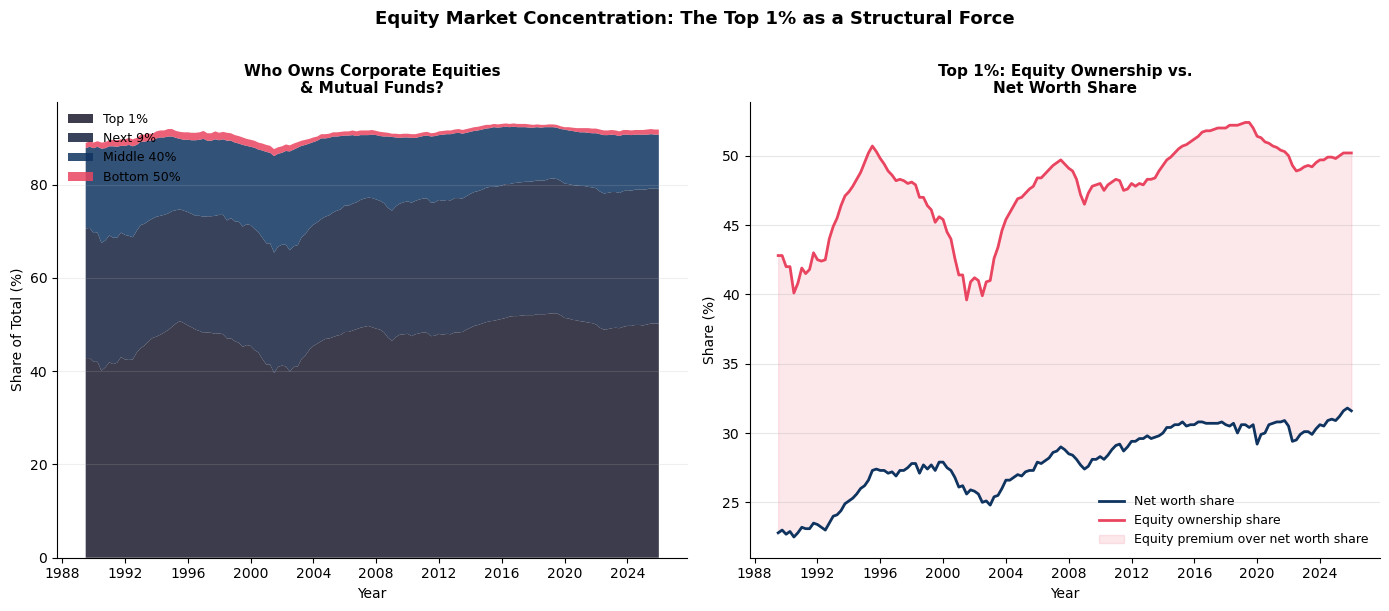

In [16]:
eq = pd.DataFrame({
    'Top 1%':     eq_top1,
    'Next 9%':    eq_next9,
    'Middle 40%': eq_mid40,
    'Bottom 50%': eq_bot50,
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: stacked area
ax = axes[0]
ax.stackplot(eq.index,
             eq['Top 1%'], eq['Next 9%'], eq['Middle 40%'], eq['Bottom 50%'],
             labels=['Top 1%', 'Next 9%', 'Middle 40%', 'Bottom 50%'],
             colors=['#1a1a2e', '#16213e', '#0f3460', '#e94560'],
             alpha=0.85)
ax.set_title('Who Owns Corporate Equities\n& Mutual Funds?', fontsize=11, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Share of Total (%)', fontsize=10)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# Right panel: equity share vs. net worth share for top 1%
ax2 = axes[1]
common = nw_top1.index.intersection(eq_top1.index)
ax2.plot(common, nw_top1.loc[common], label='Net worth share', color='#0f3460', linewidth=2)
ax2.plot(common, eq_top1.loc[common], label='Equity ownership share', color='#e94560', linewidth=2)
ax2.fill_between(common,
                 nw_top1.loc[common],
                 eq_top1.loc[common],
                 alpha=0.12, color='#e94560',
                 label='Equity premium over net worth share')
ax2.set_title('Top 1%: Equity Ownership vs.\nNet Worth Share', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Share (%)', fontsize=10)
ax2.legend(fontsize=9, frameon=False)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Equity Market Concentration: The Top 1% as a Structural Force',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_equity_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The top 1% consistently owns a *larger* share of corporate equities than their already-large share of total net worth — their portfolio is more equity-heavy than their wealth position alone would imply. The bottom 50% holds a negligible slice of equities. This asymmetry is the core mechanism behind wealth concentration's market influence: when the top 1% repositions their portfolio, they move prices in ways that ripple through the entire financial system.

---
## Figure 3: Asset Composition by Wealth Tier — Why Portfolios Differ

The previous figures establish *that* the top 1% dominates equity markets. This figure asks *why* — by comparing what each group actually holds. We use the most recent quarter's dollar-level data to compute the asset mix for the top 1% and the bottom 50%.

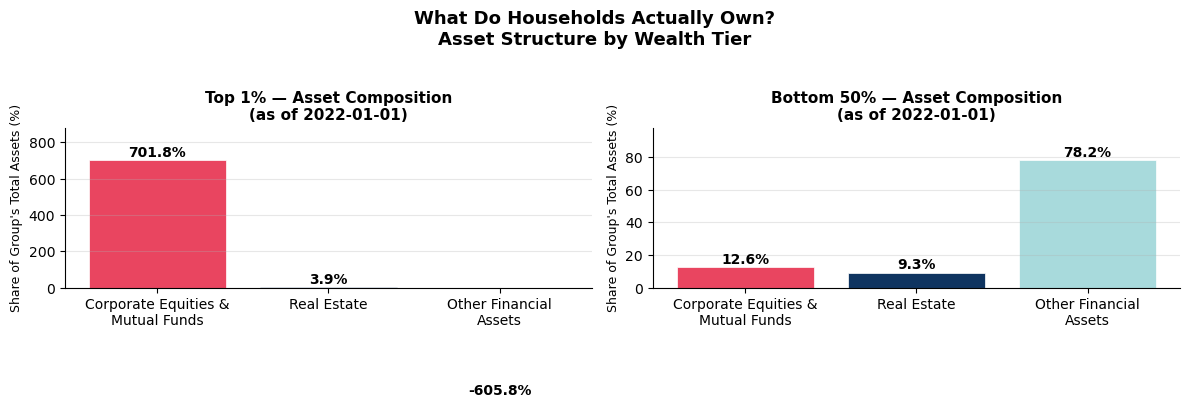

In [17]:
comp = pd.DataFrame({
    'eq_top1':   eq_lev_top1,
    're_top1':   re_lev_top1,
    'fa_top1':   fa_lev_top1,
    'eq_bot50':  eq_lev_bot50,
    're_bot50':  re_lev_bot50,
    'fa_bot50':  fa_lev_bot50,
}).dropna()

latest = comp.iloc[-1]
latest_label = str(comp.index[-1].date())

# 'Other financial assets' = financial assets minus equities (equities are a subset)
top1_eq  = latest['eq_top1']
top1_re  = latest['re_top1']
top1_oth = latest['fa_top1'] - top1_eq

bot50_eq  = latest['eq_bot50']
bot50_re  = latest['re_bot50']
bot50_oth = latest['fa_bot50'] - bot50_eq

# Convert to percentage of each group's total
top1_total  = top1_eq  + top1_re  + top1_oth
bot50_total = bot50_eq + bot50_re + bot50_oth

top1_pcts  = [top1_eq/top1_total*100,   top1_re/top1_total*100,   top1_oth/top1_total*100]
bot50_pcts = [bot50_eq/bot50_total*100, bot50_re/bot50_total*100, bot50_oth/bot50_total*100]

asset_labels = ['Corporate Equities &\nMutual Funds', 'Real Estate', 'Other Financial\nAssets']
bar_colors   = ['#e94560', '#0f3460', '#a8dadc']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, pcts, group_title in zip(axes,
                                  [top1_pcts, bot50_pcts],
                                  ['Top 1%', 'Bottom 50%']):
    bars = ax.bar(asset_labels, pcts, color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(pcts) * 1.25)
    ax.set_title(f'{group_title} — Asset Composition\n(as of {latest_label})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel("Share of Group's Total Assets (%)", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('What Do Households Actually Own?\nAsset Structure by Wealth Tier',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_asset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The portfolios of the top 1% and bottom 50% are structurally different. The top 1% holds a large proportion of their assets in corporate equities and liquid financial instruments — assets whose prices are set in open markets. The bottom 50% hold proportionally more real estate, which is illiquid and locally priced. This structural difference is why the top 1%'s portfolio decisions generate market price signals that affect all participants, while the bottom 50%'s asset decisions have minimal market impact.

---
## Figure 4: Wealth Concentration Through Economic Shocks

The final figure tests the dynamic hypothesis: do economic crises concentrate wealth further, or do they temporarily redistribute it downward?

We compute the year-over-year change in the top 1%'s net worth share using `.diff(4)` (a 4-quarter lag on quarterly data), and overlay NBER recession windows to reveal the directional pattern around each major shock.

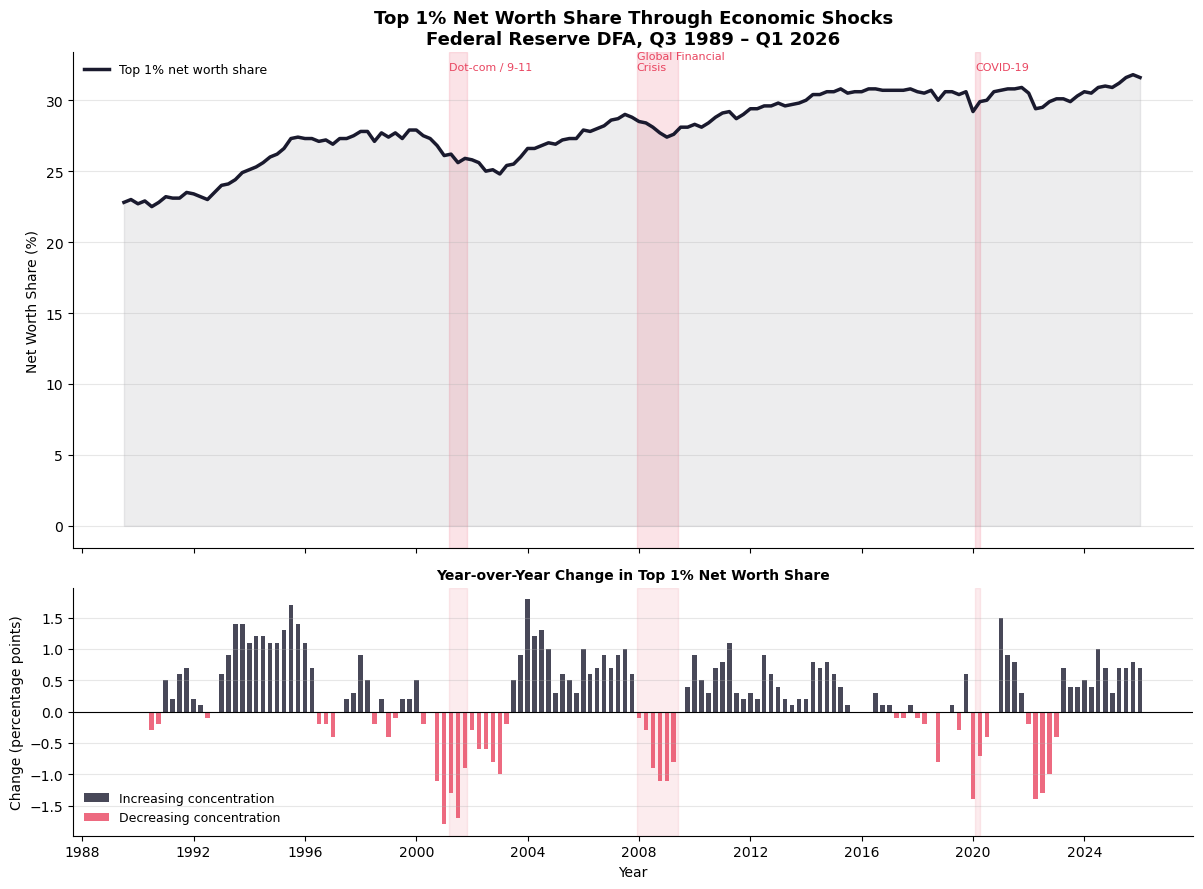

In [19]:
nw_top1_clean = nw_top1.dropna()
yoy = nw_top1_clean.diff(4)   # year-over-year change (4 quarters)

recessions = [
    ('2001-03-01', '2001-11-01', 'Dot-com / 9-11'),
    ('2007-12-01', '2009-06-01', 'Global Financial\nCrisis'),
    ('2020-02-01', '2020-04-01', 'COVID-19'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top panel: level
ax1.plot(nw_top1_clean.index, nw_top1_clean,
         color='#1a1a2e', linewidth=2.5, label='Top 1% net worth share')
ax1.fill_between(nw_top1_clean.index, nw_top1_clean, alpha=0.08, color='#1a1a2e')

for start, end, label in recessions:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='#e94560')
    ax1.text(pd.Timestamp(start), nw_top1_clean.max() * 1.005,
             label, fontsize=8, color='#e94560', ha='left', va='bottom')

ax1.set_title('Top 1% Net Worth Share Through Economic Shocks\n'
              'Federal Reserve DFA, Q3 1989 – Q1 2026',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Net Worth Share (%)', fontsize=10)
ax1.legend(fontsize=9, frameon=False)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Bottom panel: year-over-year change
ax2.bar(yoy.index, yoy.clip(lower=0), width=60,
        color='#1a1a2e', alpha=0.8, label='Increasing concentration')
ax2.bar(yoy.index, yoy.clip(upper=0), width=60,
        color='#e94560', alpha=0.8, label='Decreasing concentration')
ax2.axhline(0, color='black', linewidth=0.8)

for start, end, _ in recessions:
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color='#e94560')

ax2.set_title('Year-over-Year Change in Top 1% Net Worth Share', fontsize=10, fontweight='bold')
ax2.set_ylabel('Change (percentage points)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.legend(fontsize=9, frameon=False)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_shocks.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Across all three major crises, the pattern is asymmetric. The top 1%'s share dips briefly during the acute phase of each shock — most sharply during the dot-com bust, when equity markets fell steeply and equities dominate top-1% portfolios — then rebounds strongly in the recovery. COVID-19 is the most dramatic case: a brief dip in Q1–Q2 2020 was followed by the fastest and largest rebound on record, driven by the K-shaped recovery in which financial assets recovered within months while labor income remained depressed for years. Crises do not durably redistribute wealth downward — they briefly disrupt the top, then reconcentrate it.

In [21]:
## Figure 5: Carbon Emissions by Global Income Percentile — The Climate Cost of Wealth Concentration


In [27]:
---
## Figure 5: Carbon Inequality: The Climate Cost of Wealth Concentration

Wealth concentration is not only a financial phenomenon: it has a direct climate consequence. 
Research by the Stockholm Environment Institute (SEI) and Oxfam shows that consumption emissions 
are highly unequal across income groups: the richest 1% globally emit as much CO2 as the 
poorest two-thirds of humanity combined (2019 data).

We pull this data directly from SEI's public Emissions Inequality Dashboard API for 2019  
the most recent year available  and visualize per-capita emissions and emission shares across 
the global income distribution. We then add the critical climate context: what happens to the 
1.5°C carbon budget if everyone emitted at the top 1%'s rate?

SyntaxError: unterminated string literal (detected at line 9) (2147457764.py, line 9)

In [28]:
import json
import urllib.request

In [29]:
url = 'https://www.sei-eqtrans-dev.net/api/globalHistoricalDataByYear/search.php?startyear=2019&endyear=2019'
with urllib.request.urlopen(url) as response:
    raw = json.loads(response.read().decode())

In [30]:
# --- Fetch SEI global emissions data for 2019 via the public API ---
url = 'https://www.sei-eqtrans-dev.net/api/globalHistoricalDataByYear/search.php?startyear=2019&endyear=2019'
with urllib.request.urlopen(url) as response:
    raw = json.loads(response.read().decode())

sei = pd.DataFrame(raw['records'])
sei['EmissionShare'] = sei['EmissionShare'].astype(float)
sei['PopulationShare'] = sei['PopulationShare'].astype(float)
sei['Year'] = sei['Year'].astype(int)


In [31]:
# Keep only 2019, 1-percentile rows (PercentileValue == 0.01)
sei_2019 = sei[(sei['Year'] == 2019) & (sei['PercentileValue'].astype(float) == 0.01)].copy()
sei_2019 = sei_2019.reset_index(drop=True)

In [32]:
# Compute per-capita emission share (EmissionShare / PopulationShare = relative emission intensity)
# Global total CO2 in 2019 = 37.1 Gt (SEI/Oxfam 2023)
GLOBAL_CO2_2019_GT = 37.1
sei_2019['per_capita_tCO2'] = (sei_2019['EmissionShare'] / sei_2019['PopulationShare']) * \
                               (GLOBAL_CO2_2019_GT * 1e9 / 8_000_000_000)  # convert to tCO2/person


In [38]:
# The API returns 1-percentile rows labeled p0p1 through p98p99,
# then sub-percentile rows for the top 1% (p99p99.1, p99.1p99.2, etc.)
# We need to sum all rows where the label starts with 'p99' for the top 1%

# Filter to only the 1-percentile rows (PercentileValue == '0.01') for clean grouping
sei_1pct = sei_2019[sei_2019['PercentileValue'].astype(float) == 0.01].copy()
sei_1pct = sei_1pct.reset_index(drop=True)

# Also get ALL top-1% sub-rows (p99p99.1 etc.) for the top 1% total
sei_top1_all = sei[(sei['Year'] == 2019) & 
                    (sei['PercentileLabel'].str.startswith('p99'))].copy()

# Aggregate
groups = {
    'Bottom 50%': sei_1pct.iloc[:50]['EmissionShare'].sum(),
    'Middle 40%': sei_1pct.iloc[50:90]['EmissionShare'].sum(),
    'Next 9%':    sei_1pct.iloc[90:99]['EmissionShare'].sum(),
    'Top 1%':     sei_top1_all['EmissionShare'].sum(),   # all p99... rows
}

group_percap = {
    'Bottom 50%': sei_1pct.iloc[:50]['per_capita_tCO2'].mean(),
    'Middle 40%': sei_1pct.iloc[50:90]['per_capita_tCO2'].mean(),
    'Next 9%':    sei_1pct.iloc[90:99]['per_capita_tCO2'].mean(),
    'Top 1%':     (groups['Top 1%'] / 0.01) * (GLOBAL_CO2_2019_GT * 1e9 / 8_000_000_000),
}

In [40]:
sei_1pct['per_capita_tCO2'] = (sei_1pct['EmissionShare'] / sei_1pct['PopulationShare']) * \
                               (GLOBAL_CO2_2019_GT * 1e9 / 8_000_000_000)

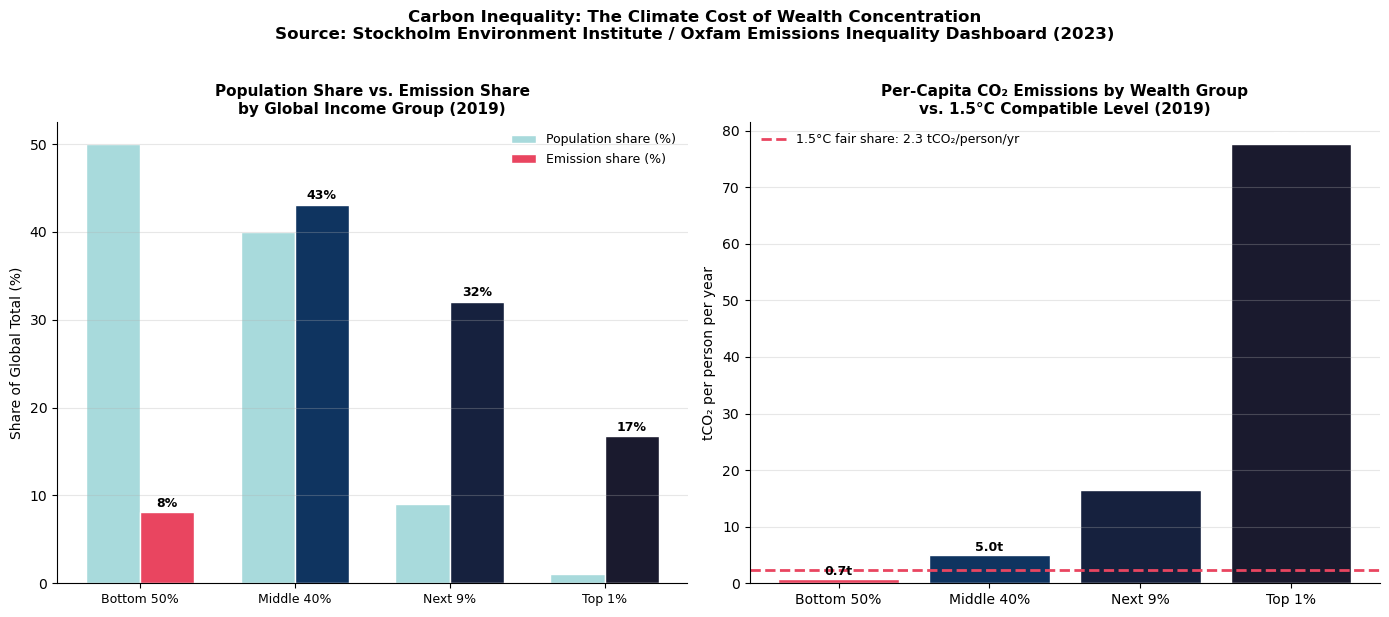


Top 1% per-capita emissions (2019): 77.6 tCO₂/person/year
If everyone emitted at this rate: 621 Gt CO₂/year
1.5°C budget (300 Gt from 2020) would be exhausted in: 0.5 years


In [41]:
# --- Carbon budget context ---
# Remaining 1.5°C budget as of 2020: 300 Gt CO2 (IPCC / SEI 2023)
# If everyone on Earth (8bn) emitted at the top 1%'s per-capita rate:
top1_percap = group_percap['Top 1%']
global_pop  = 8_000_000_000
hypothetical_annual_gt = (top1_percap * global_pop) / 1e9
budget_years = 300 / hypothetical_annual_gt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: emission SHARE vs population share (the inequality gap)
group_names  = list(groups.keys())
emit_shares  = [groups[g] * 100 for g in group_names]
pop_shares   = [50, 40, 9, 1]
colors       = ['#e94560', '#0f3460', '#16213e', '#1a1a2e']

x = np.arange(len(group_names))
width = 0.35

ax = axes[0]
bars1 = ax.bar(x - width/2, pop_shares,  width, label='Population share (%)', color='#a8dadc', edgecolor='white')
bars2 = ax.bar(x + width/2, emit_shares, width, label='Emission share (%)',    color=colors,   edgecolor='white')

for bar, val in zip(bars2, emit_shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(group_names, fontsize=9)
ax.set_title('Population Share vs. Emission Share\nby Global Income Group (2019)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Share of Global Total (%)', fontsize=10)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Right panel: per-capita tCO2 vs the 1.5°C fair share
FAIR_SHARE_15C = 2.3   # tCO2/person/year compatible with 1.5°C by 2030 (SEI)
percap_vals = [group_percap[g] for g in group_names]

ax2 = axes[1]
bars3 = ax2.bar(group_names, percap_vals, color=colors, edgecolor='white')
ax2.axhline(FAIR_SHARE_15C, color='#e94560', linewidth=2, linestyle='--',
            label=f'1.5°C fair share: {FAIR_SHARE_15C} tCO₂/person/yr')

for bar, val in zip(bars3, percap_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}t', ha='center', va='bottom', fontsize=9, fontweight='bold', color='white'
             if val > 5 else 'black')

ax2.set_title('Per-Capita CO₂ Emissions by Wealth Group\nvs. 1.5°C Compatible Level (2019)',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('tCO₂ per person per year', fontsize=10)
ax2.legend(fontsize=9, frameon=False)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Carbon Inequality: The Climate Cost of Wealth Concentration\n'
             'Source: Stockholm Environment Institute / Oxfam Emissions Inequality Dashboard (2023)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_carbon_inequality.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the budget headline number
print(f'\nTop 1% per-capita emissions (2019): {top1_percap:.1f} tCO₂/person/year')
print(f'If everyone emitted at this rate: {hypothetical_annual_gt:.0f} Gt CO₂/year')
print(f'1.5°C budget (300 Gt from 2020) would be exhausted in: {budget_years:.1f} years')

In [42]:
---
## Summary and Conclusions

This notebook used two independent datasets — the Federal Reserve's Distributional Financial 
Accounts and the Stockholm Environment Institute's Emissions Inequality Dashboard — to examine 
wealth concentration as both a financial and a climate phenomenon. The evidence across five 
figures is consistent and mutually reinforcing.

**On financial markets:** The top 1% of U.S. households have increased their share of total 
net worth from roughly 24% in 1989 to over 30% by the mid-2020s, while the bottom 50% have 
remained near or below zero. This concentration is not evenly distributed across asset classes: 
the top 1% hold a share of corporate equities and mutual fund shares that *exceeds* their 
already-large share of net worth, while the bottom 50% holds proportionally more real estate — 
an illiquid, locally-priced asset with minimal market reach. The consequence is structural: 
when the top 1% repositions its portfolio, it generates price signals that ripple through 
capital markets for everyone else. And when economic crises hit, this dynamic does not 
durably reverse — all three major shocks since 1989 produced brief dips in the top 1%'s 
share followed by faster, larger rebounds.

**On climate:** Wealth concentration is not only a financial outcome — it is a driver of 
carbon emissions. The top 1% of global income earners account for roughly 16% of global 
consumption emissions while representing 1% of the world's population, emitting at a rate 
many times above the ~2.3 tCO₂/person/year compatible with the 1.5°C Paris goal. If 
everyone on Earth consumed at that rate, the remaining 1.5°C carbon budget would be 
exhausted in just a few years. Meanwhile, the bottom 50% — who bear the greatest burden 
of climate impacts — emit well below a fair share.

**The connecting thread:** The same structural asymmetry that gives the top 1% outsized 
influence over capital markets also gives them outsized responsibility for the climate 
crisis. Their portfolios — dominated by corporate equities — are the mechanism through 
which both dynamics operate. This is why carbon inequality and financial inequality are 
not parallel crises to be addressed separately: they share a common driver, and any 
serious response to one must reckon with the other.

---
## Data Citations

**Federal Reserve Distributional Financial Accounts (DFA)**  
Board of Governors of the Federal Reserve System (US). Distributional Financial Accounts 
[multiple series]. Retrieved from FRED, Federal Reserve Bank of St. Louis.  
https://fred.stlouisfed.org/release?rid=453  
Series used: WFRBST01134, WFRBSB50215, WFRBSN09161, WFRBSN40188, WFRBST01122, 
WFRBSB50203, WFRBSN09136, WFRBSN40176, WFRBLT01014, WFRBLT01018, WFRBLT01006, 
WFRBLB50095, WFRBLB50099, WFRBLB50085.

**SEI Emissions Inequality Dashboard**  
Ghosh, E., Nazareth, A., Wang, G., Kartha, S., & Kemp-Benedict, E. (2021). 
*Emissions Inequality Dashboard*. Stockholm Environment Institute (SEI).  
https://emissions-inequality.org  
Data accessed via public API: https://emissions-inequality.org/api/  
Underlying report: Oxfam International. *Climate Equality: A Planet for the 99%*. 
Oxfam International (2023). https://doi.org/10.21201/2023.000001

SyntaxError: invalid character '—' (U+2014) (561890080.py, line 4)

---
## Summary and Conclusions

This notebook used the Federal Reserve's Distributional Financial Accounts to examine whether wealth concentration among the top 1% of U.S. households constitutes a structural driver of capital market dynamics. The evidence across four figures is consistent:

1. **Net worth concentration has grown** since 1989 — the top 1%'s share rising from ~24% to over 30%, while the bottom 50%'s share has remained near or below zero.
2. **The top 1% dominates equity ownership**, holding a share of corporate equities that exceeds their already-large share of total net worth.
3. **Portfolio structure explains market influence**: the top 1%'s wealth is concentrated in liquid financial instruments whose prices are set in open markets. The bottom 50% holds proportionally more real estate — illiquid and locally priced.
4. **Economic crises do not durably redistribute wealth**: all three major shocks produced brief dips in the top 1%'s share, followed by rapid and larger rebounds.

**Hypothesis result: Supported.** Wealth concentration is not merely a distributional outcome — it is a structural input into capital markets. When the top 1% owns the majority of corporate equities and their portfolios are dominated by financial assets, the preferences and decisions of a tiny fraction of the population set the conditions for everyone else.

---
### Data Citation

Board of Governors of the Federal Reserve System (US), Distributional Financial Accounts [multiple series], retrieved from FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/release?rid=453